## Snippet 1- Frequency tables and probability mass functions
This snippet continues Chapter 3 by moving from simple counts to probabilities. It begins with a frequency table that summarizes observed values, then converts those counts into a probability mass function, and finally shows how probabilities can be accessed and adjusted as we begin working with distributions.

In [ ]:

"""
Context: introduces frequency tables and PMFs, later probability work depends on this
Plain-English: builds counts from data, converts them to probabilities, then inspects and updates them
Real-world: used when turning observed data into probability models
Reappears: yes across distributions and probability analysis
"""

# empiricaldist library provides a "Pmf" object that represents a probability mass function,
# so instead of creating a FreqTab object and then normalizing it, we can create a Pmf object directly.
# "normalize" method renormalizes the Pmf by dividing through by the sum and returning the sum.
# "copy" method can make and modify a copy without affecting the original.

from empiricaldist import FreqTab  # class for counting occurrences

ftab = FreqTab.from_seq([1, 2, 2, 3, 5])  
# create frequency table from sequence

print(
    ftab
     )  
# display counts for each value

n = ftab.sum()  
# compute total number of observations

print(n)  
# display total count

pmf = ftab / n  
# convert counts to probabilities

print(
    pmf
     )  
# display probability distribution

print(
    "Total probability=", pmf.sum()
     )  
# verify probabilities sum to 1 which means that whether the distribution is normalized or not


from empiricaldist import Pmf  
# class for probability mass functions

pmf = Pmf.from_seq([1, 2, 2, 3, 5])  
# create normalized PMF directly

print(
    pmf
     )  
# display probabilities

print(
    "Total probability by Pmf = ", pmf.sum()
     )  
# check total probability

print(
    pmf[2]
     )  
# look up the probability of value 2

print(
    pmf(2)
     )  
# alternative access method

pmf[2] = 0.2  
# overwrite probability at value 2

print(
    "Overwrite prob =  ", pmf(2)
     )  
# confirm update

pmf[2] += 0.3  
# modify an existing pmf by incrementing probability at value 2

print(
    "Updated value = ", pmf[2]
     )  
# view updated value

pmf[2] *= 0.5  
# scale probability at value 2

print(
    "Scaled value = ", pmf[2]
     )  
# view scaled value

print(
    "Total after manual edits =", pmf.sum()
     )  
# check total after manual edits

print(
    "re-normalize prob= ", pmf.normalize()
     )  
# re-normalize probabilities to sum to 1

print(
    "Copy=", pmf.copy()
     )  
# create independent copy

"""
Interpretation:
FreqTab stores counts, Pmf stores probabilities
sum checks total mass, indexing and call both read values
manual edits break normalization, normalize restores balance, copy creates separate object

"""

print()

1    1
2    2
3    1
5    1
Name: , dtype: int64
5
1    0.2
2    0.4
3    0.2
5    0.2
Name: , dtype: float64
Total probability= 1.0
1    0.2
2    0.4
3    0.2
5    0.2
Name: , dtype: float64
Total probability by Pmf =  1.0
0.4
0.4
Overwrite prob =   0.2
Updated value =  0.5
Scaled value =  0.25
Total after manual edits = 0.8500000000000001
re-normalize prob=  0.8500000000000001
Copy= 1    0.235294
2    0.294118
3    0.235294
5    0.235294
Name: , dtype: float64



## Snippet 2- Mean, variance, and summary statistics from a PMF
This snippet continues by computing summary statistics from a distribution. It first calculates the mean directly from raw data, then uses a probability mass function to compute mean, variance, standard deviation, and mode, showing how distributions support statistical summaries.

In [ ]:
# Distributions

"""
Context: introduces summary statistics from sequences and PMFs, later analysis relies on these measures
Plain-English: computes mean from raw data and PMF, then derives variance, standard deviation, and mode
Real-world: used to summarize central tendency and spread of data distributions
Reappears: yes in statistical summaries and comparisons
"""

import numpy as np

seq = [1, 2, 2, 3, 5]  
# sample data sequence

n = len(seq)  
# count number of elements (where "len" is the size or length of the sequence)

mean = np.sum(seq) / n  
# compute mean from raw data

print(
    "Mean from sequence = ", mean
     )  
# display raw mean

pmf = Pmf.from_seq(seq)  
# create PMF from sequence

mean = np.sum(pmf.ps * pmf.qs)  
# weighted mean using probabilities and values
# where ps refers probability and qs refers quantity in Pmf function

print(
    "Mean from pmf = ", mean
     )  
# display PMF-based mean

print(
    "Mean using method = ", pmf.mean()
     )  
# Pmf objects have a mean method that does the same thing to compute mean

deviations = pmf.qs - mean  
# difference between values and mean

var = np.sum(pmf.ps * deviations**2)  
# compute variance

print(
    "Variance manual = ", var
     )  
# display variance

print(
    "Variance method = ", pmf.var()
     )  
# built-in variance

print(
    "Standard deviation manual = ", np.sqrt(var)
     )  
# compute standard deviation manually

print(
    "Standard deviation method = ", pmf.std()
     )  
# built-in std 

print(
    "Mode = ", pmf.mode()
     )  
# most frequent value

"""
Interpretation:
mean from data and PMF should match, pmf.mean confirms calculation.
variance measures spread around mean, std is square root of variance,
mode shows most likely value in the distribution
"""

print()

Mean from sequence =  2.6
Mean from pmf =  2.6
Mean using method =  2.6
Variance manual =  1.84
Variance method =  1.84
Standard deviation manual =  1.3564659966250536
Standard deviation method =  1.3564659966250536
Mode =  2



## Snippet 3- Building a PMF from grouped class sizes
This snippet works with grouped data instead of individual values. It defines class-size intervals, assigns counts to each group, and builds a probability mass function using representative values so the distribution can still be analyzed.

In [ ]:
# Distributions

"""
Context: introduces grouped data as a distribution, later comparisons use this PMF
Plain-English: builds intervals, stores counts, then turns grouped frequencies into a PMF
Real-world: used when data is reported in bins instead of exact values
Reappears: yes when approximating real distributions from summarized data

"""

import pandas as pd

# pd.interval_range() function in Pandas is used to create an interval index
# Arguments for pd.interval_range() are-
# start (required): The starting point of the intervals.
# end (required): The endpoint of the intervals.
# freq (optional): Specifies the step size or interval frequency.
# closed (optional): Defines which side of the interval is closed (i.e., which side includes the boundary)
# closed='right' (default): Interval is closed on the right side, meaning it includes the right boundary
# name (optional): Allows you to set a name for the resulting IntervalIndex

ranges = pd.interval_range(start=5, end=50, freq=5, closed="left")  
# create left-closed class intervals from 5 to 50

ranges.name = "class size"  
# label the interval index

print(
    ranges
     )
data = pd.DataFrame(index=ranges)  
# create a table using intervals as the index

data["count"] = [8, 8, 14, 4, 6, 12, 8, 3, 2]  
# store observed count for each class-size interval

print(
    "Grouped data= ", data
     )  
# display the interval table with counts

sizes = ranges.left + 2  
# use interior representative values for each interval

print(
    "Representative sizes = ", sizes
     )  
# display the values used to represent each bin/ the midpoint of the range

counts = data["count"]  
# extract the count column



# Arguments for Pmf() funtion from FreqTab are-
# "counts": List/Array/or Pandas Series represents the frequencies or counts of each discrete event
# "sizes": contains the discrete categories/ or events for which the counts are provided
# "name" (optional): A label for the Pmf object.
# "normalize" (optional): True, ensures the Pmf is normalized (i.e., the sum of probabilities is 1).
# it divides each count by the sum of all counts. So each class size's probability becomes something 
# & the sum of these probabilities will be 1.

actual_pmf = Pmf(counts.values, index=sizes, name="actual") 
# build a PMF from counts and representative sizes

print(
    actual_pmf
    )

print(
    "Normalize result = ", actual_pmf.normalize()
     )  
# normalize counts into probabilities

print(
    "Mean class size for college = ", actual_pmf.mean()
     )  
# compute the mean from the grouped PMF

"""
Interpretation:
intervals define grouped class sizes, counts store observed frequency
Pmf uses representative sizes and counts, normalize converts counts to probabilities
mean gives the average class size from this grouped distribution
"""

print()

IntervalIndex([ [5, 10), [10, 15), [15, 20), [20, 25), [25, 30), [30, 35),
               [35, 40), [40, 45), [45, 50)],
              dtype='interval[int64, left]', name='class size')
Grouped data=              count
class size       
[5, 10)         8
[10, 15)        8
[15, 20)       14
[20, 25)        4
[25, 30)        6
[30, 35)       12
[35, 40)        8
[40, 45)        3
[45, 50)        2
Representative sizes =  Index([7, 12, 17, 22, 27, 32, 37, 42, 47], dtype='int64')
7      8
12     8
17    14
22     4
27     6
32    12
37     8
42     3
47     2
Name: actual, dtype: int64
Normalize result =  65
Mean class size for college =  23.692307692307693



## Snippet 4- Bias and debiasing in class size distributions
This snippet introduces the idea of bias that appears when sampling from grouped data. It builds a biased distribution based on class size, compares it with the original, and then shows how to reverse that effect to recover the underlying distribution.

Observed mean =  29.123376623376622
Debiased mean =  23.692307692307693



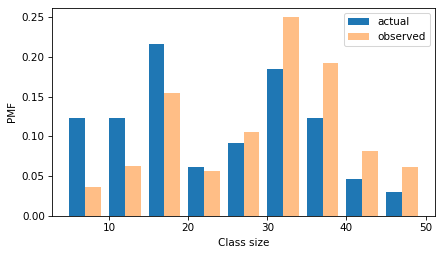

In [ ]:
# Distributions

"""
Context: introduces sampling bias in grouped data, later comparisons rely on this correction
Plain-English: creates a biased PMF, compares it to the original, then removes the bias
Real-world: appears when larger groups are more likely to be observed in samples
Reappears: yes in sampling and real-world data interpretation
"""

from empiricaldist import Pmf  
from thinkstats import two_bar_plots, decorate  # plotting helpers

# "new Pmf" reflects student perception of the class sizes as seen by students
# The quantities in the two distributions are the same, but the probabilities in the distribution are multiplied by..
# the quantities (class sizes), because in a class with size x, there are x students who observe that class. 
# So the probability of observing a class is proportional to its size.
# A larger class size means that class is observed more frequently, so its probability should be weighted by the class size.


def bias(pmf, name): 
    # pmf: The original probability mass function that contains the class sizes and their probabilities.
    # name: A string that will be used as the name or label of the new Pmf object being created inside the function.
    
    ps = pmf.ps * pmf.qs    
    # multiply each probability by class size
     
    new_pmf = Pmf(ps, pmf.qs, name=name) 

    # create new PMF using adjusted/weighted probabilities
    # "name" pass the string name to the Pmf class constructor, setting the name of the new Pmf object.

    new_pmf.normalize()  # normalize to sum to 1
    return new_pmf  # return biased PMF

observed_pmf = bias(actual_pmf, name="observed")  
# apply bias to actual distribution which observed by students

print(
    "Observed mean = ", observed_pmf.mean()
     )  
# mean after bias

two_bar_plots(actual_pmf, observed_pmf, width=2)  
# compare original and biased PMFs

decorate(xlabel="Class size", ylabel="PMF")  
# label plot


def unbias(pmf, name):
    ps = pmf.ps / pmf.qs 
    # divide each probability by class size

    new_pmf = Pmf(ps, pmf.qs, name=name)  
    # rebuild PMF

    new_pmf.normalize()  
    # normalize again

    return new_pmf  
    # return debiased PMF

debiased_pmf = unbias(observed_pmf, "debiased")  
# remove bias

print(
    "Debiased mean = ", debiased_pmf.mean()
     )  
# mean after correction

"""
Interpretation:
bias increases weight of larger classes, observed PMF shifts toward bigger values
plot shows difference between actual and observed distributions
unbias reverses effect, mean moves back toward original distribution
"""

print()

## Snippet 5- Comparing pregnancy length distributions
This snippet brings the chapter’s probability tools to real survey data. It prepares the NSFG files, loads pregnancy groups, builds probability mass functions for first pregnancies and others, and then compares the two distributions on the same plot.

In [21]:
# Data Loading

"""
Context: moves from toy examples to NSFG data, later comparisons depend on these pregnancy groups
Plain-English: installs a helper if needed, downloads files, builds two PMFs, then plots them
Real-world: this pattern appears when analysis starts with external files and grouped comparisons
Reappears: yes in later data loading and distribution comparisons
"""

try:
    import statadict  
except ImportError:
    %pip install statadict 

from os.path import basename, exists  
def download(url):
    filename = basename(url)  # Extract the filename from the URL

    print(f" Downloaded {filename} from URL")
     
    if not exists(filename):
        from urllib.request import urlretrieve  
        local, _ = urlretrieve(url, filename)  
        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")  # download helper module for NSFG data access
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")  # download data dictionary
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")  # download compressed pregnancy data file


 Downloaded nsfg.py from URL
 Downloaded 2002FemPreg.dct from URL
 Downloaded 2002FemPreg.dat.gz from URL


C:\Users\DCL\AppData\Local\Temp\ipykernel_13204\3883078818.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


0        39
2        39
5        38
8        39
10       39
         ..
13576    39
13578    39
13581    39
13584    34
13588    39
Name: prglngth, Length: 4413, dtype: int64
1        39
3        39
4        39
6        40
7        42
         ..
13572    39
13574    39
13579    39
13591    39
13592    39
Name: prglngth, Length: 4735, dtype: int64
first_pmf for prglngth= prglngth
0     0.000227
17    0.000227
20    0.000227
21    0.000227
22    0.000680
23    0.000227
24    0.001586
25    0.000227
26    0.003626
27    0.000227
28    0.005438
29    0.002039
30    0.016542
31    0.003399
32    0.012463
33    0.006345
34    0.006571
35    0.036030
36    0.038976
37    0.047133
38    0.061636
39    0.479039
40    0.121459
41    0.081577
42    0.046454
43    0.019714
44    0.005212
45    0.001360
46    0.000227
47    0.000227
48    0.000680
Name: firsts, dtype: float64
other_pmf for prglngth= prglngth
4     0.000211
9     0.000211
13    0.000211
17    0.000211
18    0.000211
19    0.000211


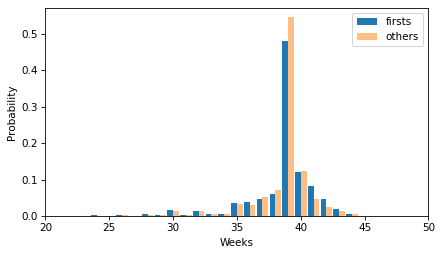

In [ ]:

# read_nsfg_groups function that reads NSFG pregnancy file and split into groups.
# it first selects rows that represent live births, and partitions live births into first babies and others


from thinkstats import decorate
import numpy as np
import pandas as pd
from statadict import parse_stata_dict


def underride(d, **kwargs):
    for key, val in kwargs.items():  
        # Add the key only if it is not already in the dictionary

        d.setdefault(key, val)
        return d  
    # Return the updated dictionary
    
def read_stata(dct_file, dat_file, **options):
    stata_dict = parse_stata_dict(dct_file)

    underride(options, compression="gzip")
    resp = pd.read_fwf(
        dat_file,
        names=stata_dict.names,
        colspecs=stata_dict.colspecs,
        **options,
    )
    return resp

def clean_fem_preg(df):
    """Recodes variables from the pregnancy frame. df: DataFrame of pregnancy data to clean.
    Modifies:
        agepreg: float age of mother at end of pregnancy
        birthwgt_lb: float birth weight in pounds
        birthwgt_oz: float birth weight in ounces
        totalwgt_lb: float total birth weight in pounds
        hpagelb: float mother's weight at last menstrual period
        babysex: int sex of baby (1=male, 2=female)
        nbrnaliv: int number of babies born alive
    """
    df.agepreg /= 100.0
    df.loc[df.birthwgt_lb > 20, "birthwgt_lb"] = np.nan
    na_vals = [97, 98, 99]
    df["birthwgt_lb"] = df.birthwgt_lb.replace(na_vals, np.nan)
    df["birthwgt_oz"] = df.birthwgt_oz.replace(na_vals, np.nan)
    df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0

    df["hpagelb"] = df.hpagelb.replace(na_vals, np.nan)
    df["babysex"] = df.babysex.replace([7, 9], np.nan)
    df["nbrnaliv"] = df.nbrnaliv.replace([9], np.nan)

def read_fem_preg(dct_file="2002FemPreg.dct", dat_file="2002FemPreg.dat.gz"):

    preg = read_stata(dct_file, dat_file)
    clean_fem_preg(preg)
    return preg

def get_nsfg_groups(): 
    # Read the NSFG pregnancy file and split into groups.

    preg = read_fem_preg()
    live = preg.query("outcome == 1")
    firsts = live.query("birthord == 1")
    others = live.query("birthord != 1")
    return live, firsts, others


live, firsts, others = get_nsfg_groups()  
# load live births, first births, and other births

# live: DataFrame of all live births
# firsts: DataFrame of first babies
# others: DataFrame of other babies

print(
    firsts["prglngth"]
     )

print(
    others["prglngth"]
     )

first_pmf = Pmf.from_seq(firsts["prglngth"], name="firsts")  
# build PMF for pregnancy length of first births

print(
    "first_pmf for prglngth=", first_pmf
     )

other_pmf = Pmf.from_seq(others["prglngth"], name="others")  
# build PMF for pregnancy length of other births

print(
    "other_pmf for prglngth=", other_pmf
     )

two_bar_plots(first_pmf, other_pmf)  
# plot the two PMFs side by side

decorate(xlabel="Weeks", ylabel="Probability", xlim=[20, 50])  
# label axes and limit the x-axis range

"""
Interpretation:
downloads prepare local files, get_nsfg_groups returns grouped survey tables
each PMF stores pregnancy length probabilities, plot compares first births and others
x-axis shows weeks, y-axis shows probability, missing files or imports cause setup errors
"""

print()

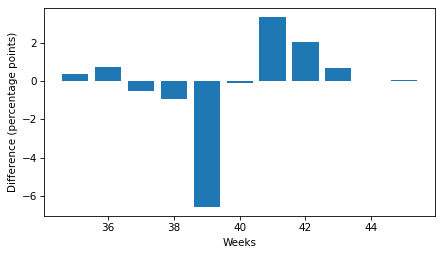

In [23]:
weeks = range(35, 46)
first_pmf(weeks)
other_pmf(weeks)
diffs = first_pmf(weeks) - other_pmf(weeks)
diffs
plt.bar(weeks, diffs * 100)
decorate(xlabel="Weeks", ylabel="Difference (percentage points)")


## Snippet 6- Difference between pregnancy length distributions
This snippet compares the two distributions more directly by focusing on differences at each week. It evaluates both PMFs over a range of weeks, computes the difference, and visualizes how the probabilities diverge across pregnancy lengths.

First PMF values =  [0.03602991 0.03897575 0.04713347 0.06163608 0.4790392  0.12145932
 0.08157716 0.04645366 0.01971448 0.00521187 0.00135962]
Other PMF values =  [0.03210137 0.03146779 0.05216473 0.07074974 0.54466737 0.12249208
 0.04794087 0.02597677 0.01288279 0.00485744 0.00084477]
Differences =  [ 0.00392854  0.00750796 -0.00503126 -0.00911366 -0.06562817 -0.00103276
  0.03363629  0.02047689  0.00683169  0.00035443  0.00051485]


'\nInterpretation:\neach value shows probability difference at a week, positive means higher for first births. Here, we can see that, first babies are less likely to be born in week 39, and somewhat more likely to be born in weeks 41 and 42\nbar height shows magnitude of difference, scaling converts to percentage points\nflat or near zero bars mean similar distributions at those weeks\n'

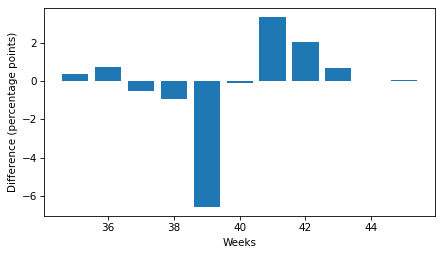

In [ ]:
# Visualization

"""
Context: compares two PMFs pointwise, later insights depend on these differences
Plain-English: evaluates both PMFs over a range, computes differences, then plots them
Real-world: used when comparing distributions across categories
Reappears: yes in comparative analysis of groups
"""

import matplotlib.pyplot as plt

weeks = range(35, 46)  
# define range of weeks to evaluate

print(
    "First PMF values = ", first_pmf(weeks)
     )  
# probabilities for first births

print(
    "Other PMF values = ", other_pmf(weeks)
     )  
# probabilities for other births

diffs = first_pmf(weeks) - other_pmf(weeks)  
# compute difference at each week

print(
    "Differences = ", diffs
     )  # display differences

plt.bar(weeks, diffs * 100)  
# plot differences scaled to percentage points

decorate(xlabel="Weeks", ylabel="Difference (percentage points)")  # label axes

"""
Interpretation:
each value shows probability difference at a week, positive means higher for first births. Here, we can see that, first babies are less likely to be born in week 39, and somewhat more likely to be born in weeks 41 and 42
bar height shows magnitude of difference, scaling converts to percentage points
flat or near zero bars mean similar distributions at those weeks
"""

## Snippet 7- PMF and skewness for number of babies
This snippet uses respondent data to study the distribution of the number of babies. It first loads the data and visualizes the PMF for Exercise 3.1, then moves to Exercise 3.2 by measuring skewness from the raw values and confirming the same result with a function that works directly on a PMF.

In [ ]:
# Distributions

"""
Context: uses respondent data to study number of babies, then measures how the distribution leans
Plain-English: loads the data, plots a PMF, computes skewness from values, then repeats it from a PMF
Real-world: useful when count data is uneven and we want both a plot and a summary measure
Reappears: yes when comparing distribution shape with numerical summaries
"""

import numpy as np
from thinkstats import decorate  
# import decorate helper to standardize plot labels and styling

# import one function to pull a filename from an online URL, and one to check whether that file is already present

from os.path import basename, exists  

def download(url):
    filename = basename(url)  # Extract the filename from the URL

    print(f" Downloaded {filename} from URL") # To check whether the file already exists in the current directory
     
    if not exists(filename):
        from urllib.request import urlretrieve  
 
        local, _ = urlretrieve(url, filename)  

    print("Downloaded " + local)
    # return object of urlretrieve is 2 items which are (filename, headers) where headers is metadata from the server


download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dct")  # download respondent dictionary
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dat.gz")  # download respondent data file

from nsfg import read_fem_resp  
# import function that reads respondent data

resp = read_fem_resp()  
# load respondent data

print(
    "Respondent shape = ", resp.shape
     )  
# display rows and columns


 Downloaded 2002FemResp.dct from URL
 Downloaded 2002FemResp.dat.gz from URL


c:\Users\DCL\Desktop\saadman vai\thinkstat\nsfg.py:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["agemarry"] = (resp.cmmarrhx - resp.cmbirth) / 12.0
c:\Users\DCL\Desktop\saadman vai\thinkstat\nsfg.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["age"] = (resp.cmintvw - resp.cmbirth) / 12.0
c:\Users\DCL\Desktop\saadman vai\thinkstat\nsfg.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining al

Respondent shape =  (7643, 3092)


numbabes =  numbabes
0     3229
1     1519
2     1603
3      828
4      309
5       95
6       29
7       15
8        8
9        2
10       3
16       1
22       1
97       1
Name: count, dtype: int64
pmf= numbabes
0.0     0.422533
1.0     0.198770
2.0     0.209762
3.0     0.108349
4.0     0.040434
5.0     0.012431
6.0     0.003795
7.0     0.001963
8.0     0.001047
9.0     0.000262
10.0    0.000393
16.0    0.000131
22.0    0.000131
Name: numbabes, dtype: float64
Skewness from values =  1.7018914266755958
Skewness from PMF =  1.7018914266755958



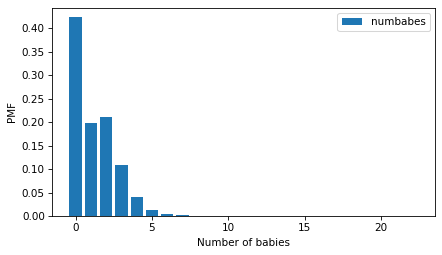

In [ ]:
"""Exercise 3.1"""

# "numbabes" records the “number of babies born alive” 

print(
     "numbabes = ", resp["numbabes"].value_counts(dropna=False).sort_index()
     )

numbabes = resp["numbabes"].replace(97, np.nan)  
# replace missing-value code with NaN

pmf = Pmf.from_seq(numbabes.dropna(), name="numbabes")  
# build PMF from valid number-of-babies values

print( 
    "pmf=", pmf
     )

pmf.bar()  
# draw bar plot of the PMF

decorate(xlabel="Number of babies", ylabel="PMF")  
# label axes



"""Exercise 3.2"""

deviations = numbabes - numbabes.mean()  
# compute distance from the mean for each value

skewness = np.mean(deviations**3) / numbabes.std(ddof=0) ** 3  
# compute skewness from the raw data

print(
    "Skewness from values = ", skewness
     )  
# display skewness from the Series


def pmf_skewness(pmf):
    # compute deviation of each possible value from the PMF mean
    
    deviations = pmf.qs - pmf.mean()

    skewness = np.sum(pmf.ps * deviations**3) / pmf.std()**3
    # weight cubed deviations by PMF probabilities

    return skewness  # return skewness computed from the PMF


print(
    "Skewness from PMF = ", pmf_skewness(pmf)
     )  
# confirm PMF-based skewness matches the value-based result

"""
Interpretation:
Exercise 3.1 plots how number of babies is distributed across respondents
Exercise 3.2 measures whether that distribution leans left or right
if both skewness values agree, the PMF is preserving the same shape as the raw data
"""

print()